# 06 — Classification: final evaluation, explainability and stacking

Three parts:

1. **Evaluate** the eight tuned classifiers on the held-out test set —
   classification report, confusion matrix and one-vs-rest ROC curves each.
2. **Explain** the MLP with SHAP, LIME, TREPAN and LORE.
3. **Stack** four complementary models and rescale their class probabilities
   to maximise Macro F1.

Equivalent to: `python main.py --stage eval-clf`

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings

import catboost as cb
import lightgbm as lgb
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.preprocessing import label_binarize
from sklearn.svm import SVC
from sklearn.utils import class_weight

from src.config import (EVAL_FIXED_PARAMS_CLF, IMPUTER_PARAMS_CLF, PATHS,
                        SII_CLASSES, SII_CLASS_NAMES, STACK_FIXED_PARAMS_CLF)
from src.data_loader import (DROP_FOR_CLASSIFICATION, load_processed_split,
                             preprocess_split)
from src.metrics import build_classification_stack, evaluate_classifier
from src.models import TorchClassifier, build_model
from src.utils import load_tuned_params

warnings.filterwarnings("ignore")

## 1. Load, impute and scale

Unlike the tuning notebooks — where preprocessing is refitted inside every fold
— here we fit it once on the full training set and apply it to the test set.
That is correct at this point: the models are done being selected, and the test
set is only ever transformed, never fitted on.

The result is kept as a DataFrame with its column names, because the
explainability methods in part 2 need to report findings in terms of real
feature names.

In [2]:
X_train_raw, y_train_clf, X_test_raw, y_test_clf = load_processed_split(
    PATHS["clf_processed"], DROP_FOR_CLASSIFICATION
)

X_train_array, X_test_array, _, _ = preprocess_split(
    X_train_raw, X_test_raw, y_train_clf, IMPUTER_PARAMS_CLF
)
X_train_scaled = pd.DataFrame(X_train_array, columns=X_train_raw.columns)
X_test_scaled = pd.DataFrame(X_test_array, columns=X_train_raw.columns)

# One-hot form of the labels, needed for the one-vs-rest ROC curves.
y_test_binary = label_binarize(y_test_clf, classes=SII_CLASSES)

print(f"Final X_train shape: {X_train_scaled.shape}")
print(f"Final X_test shape:  {X_test_scaled.shape}")

Final X_train shape: (6768, 46)
Final X_test shape:  (1692, 46)


## 2. Evaluate the seven scikit-learn classifiers

One loop instead of seven near-identical blocks. Each model is rebuilt from its
tuned parameters, fitted, and evaluated.

Two models need special handling:

- **XGBoost** has no `class_weight` argument, so imbalance is handled by
  passing balanced per-sample weights through the pipeline.
- **RidgeClassifier** has no `predict_proba`, so its decision scores are turned
  into pseudo-probabilities with a softmax purely so the ROC curves can be
  drawn.


Evaluation for LightGBM
              precision    recall  f1-score   support

           0       0.77      0.82      0.79      1167
           1       0.35      0.31      0.32       317
           2       0.27      0.23      0.25       190
           3       0.00      0.00      0.00        18

    accuracy                           0.65      1692
   macro avg       0.35      0.34      0.34      1692
weighted avg       0.62      0.65      0.64      1692

Macro AUC: 0.7069


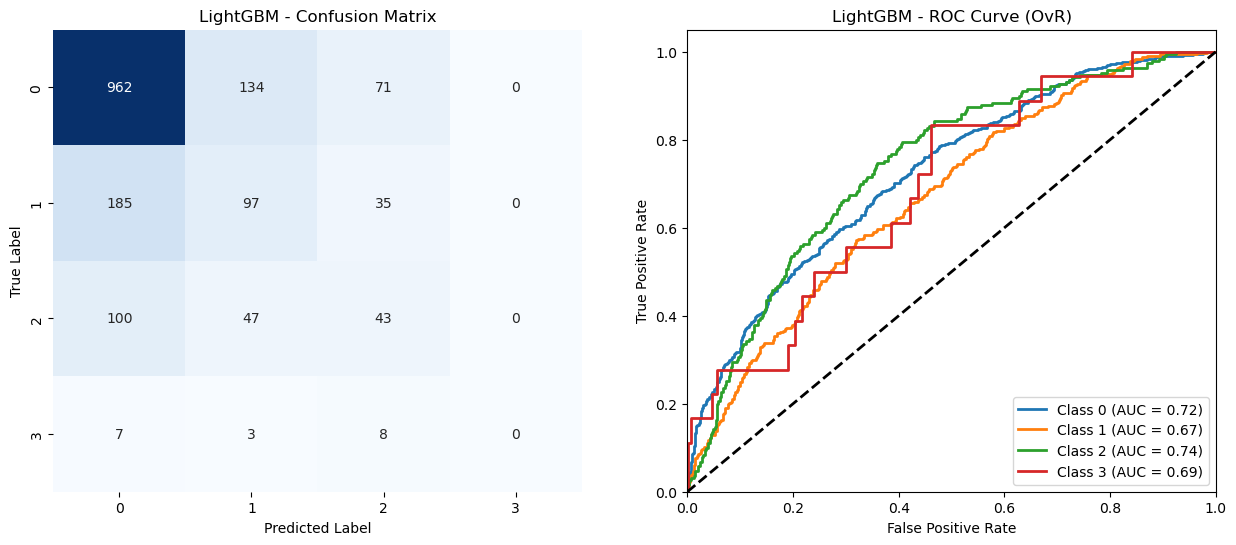


Evaluation for XGBoost
              precision    recall  f1-score   support

           0       0.80      0.75      0.77      1167
           1       0.34      0.35      0.34       317
           2       0.31      0.45      0.37       190
           3       0.25      0.06      0.09        18

    accuracy                           0.63      1692
   macro avg       0.43      0.40      0.39      1692
weighted avg       0.66      0.63      0.64      1692

Macro AUC: 0.7286


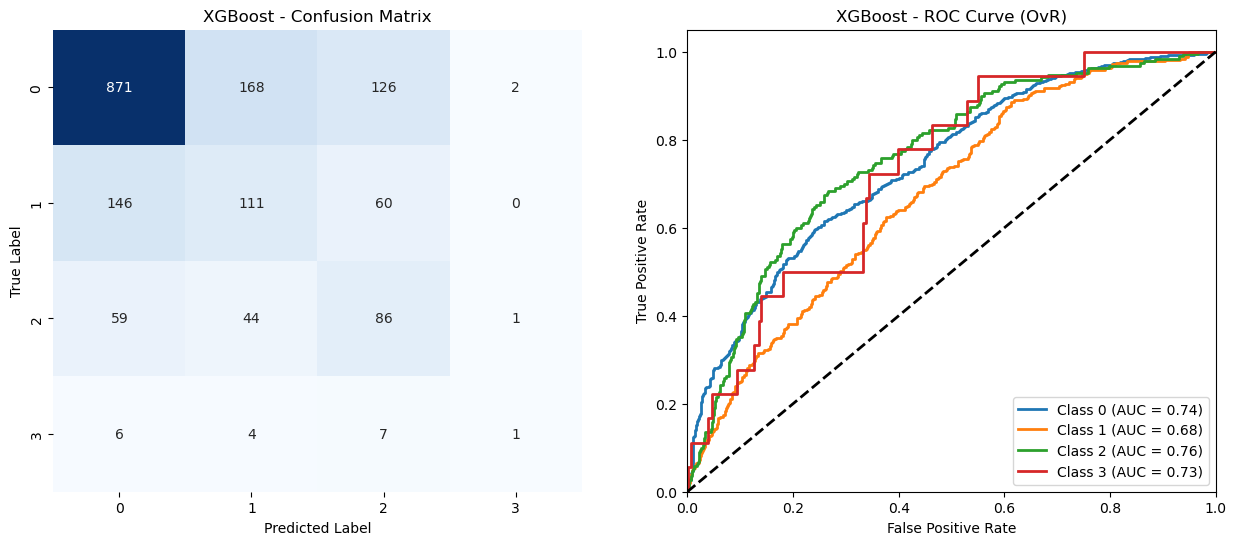


Evaluation for CatBoost
              precision    recall  f1-score   support

           0       0.81      0.67      0.74      1167
           1       0.30      0.36      0.33       317
           2       0.27      0.47      0.34       190
           3       0.07      0.06      0.06        18

    accuracy                           0.58      1692
   macro avg       0.36      0.39      0.37      1692
weighted avg       0.65      0.58      0.61      1692

Macro AUC: 0.7215


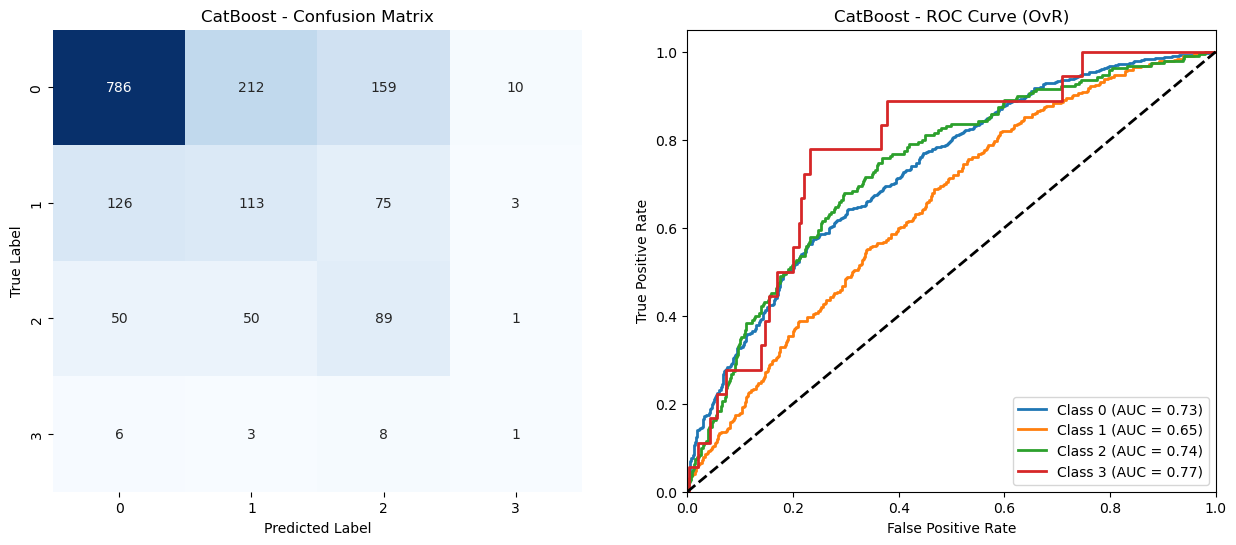


Evaluation for RandomForest
              precision    recall  f1-score   support

           0       0.73      0.96      0.83      1167
           1       0.42      0.09      0.15       317
           2       0.31      0.12      0.17       190
           3       0.00      0.00      0.00        18

    accuracy                           0.70      1692
   macro avg       0.36      0.29      0.29      1692
weighted avg       0.61      0.70      0.62      1692

Macro AUC: 0.7316


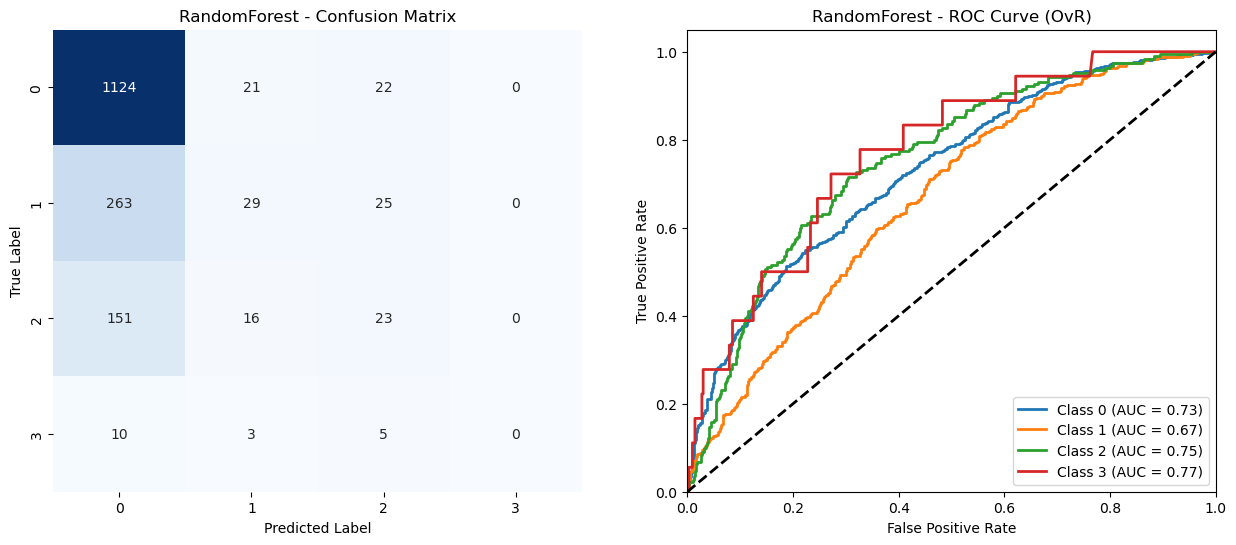


Evaluation for RidgeClassifier
              precision    recall  f1-score   support

           0       0.80      0.62      0.70      1167
           1       0.28      0.17      0.21       317
           2       0.23      0.34      0.27       190
           3       0.02      0.39      0.04        18

    accuracy                           0.50      1692
   macro avg       0.33      0.38      0.31      1692
weighted avg       0.63      0.50      0.55      1692

Macro AUC: 0.6474


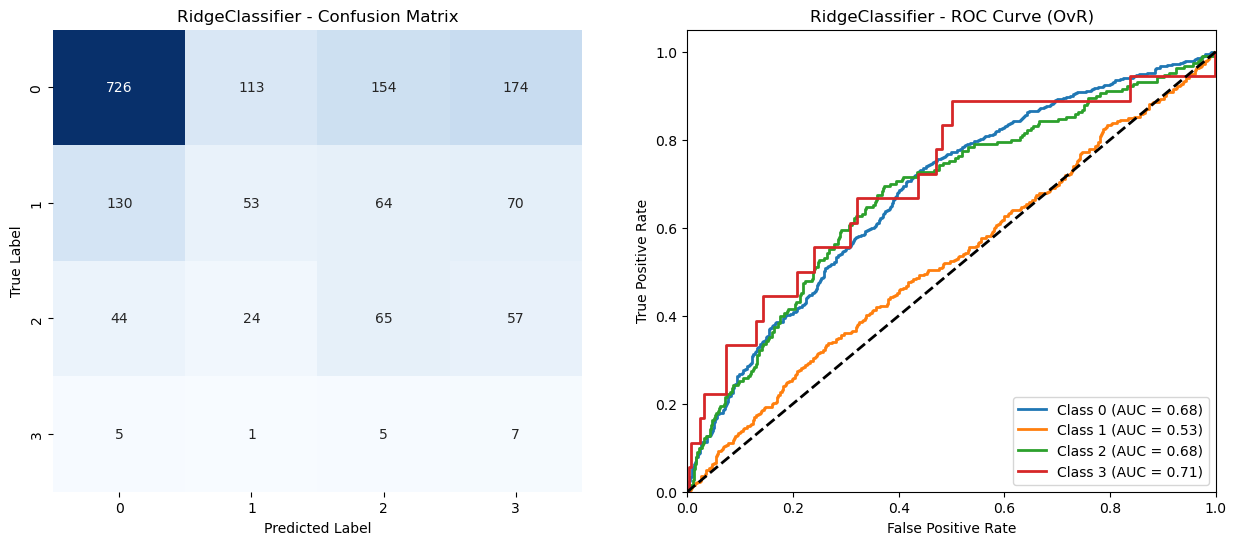


Evaluation for LogisticRegression
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      1167
           1       0.26      0.21      0.23       317
           2       0.27      0.38      0.31       190
           3       0.03      0.44      0.05        18

    accuracy                           0.50      1692
   macro avg       0.34      0.41      0.32      1692
weighted avg       0.64      0.50      0.56      1692

Macro AUC: 0.6745


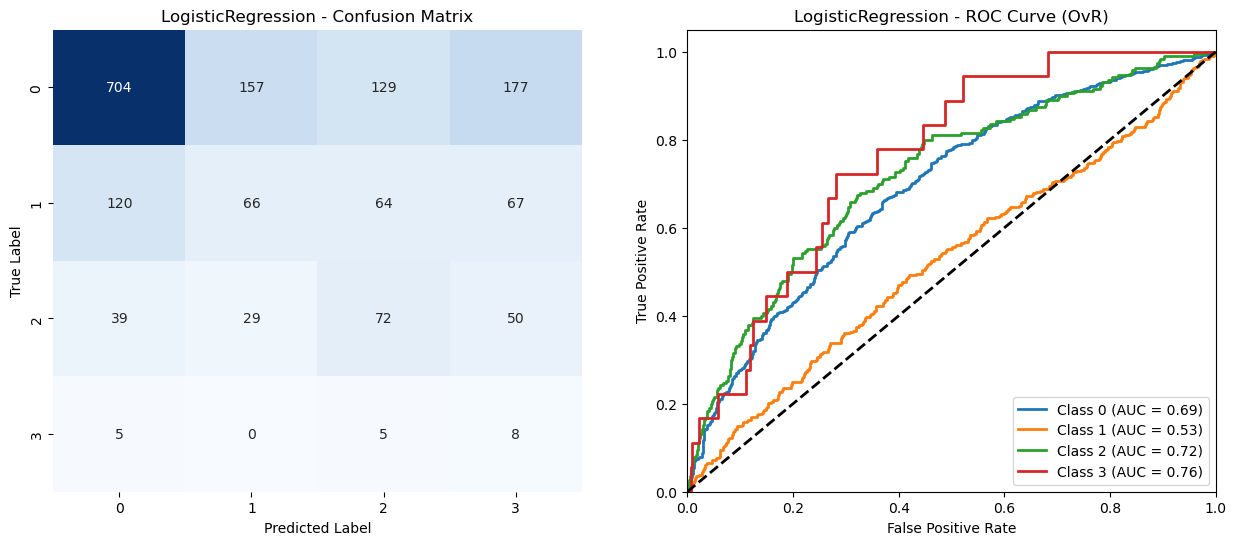


Evaluation for SVC
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      1167
           1       0.25      0.24      0.24       317
           2       0.17      0.15      0.16       190
           3       0.05      0.11      0.06        18

    accuracy                           0.57      1692
   macro avg       0.30      0.31      0.30      1692
weighted avg       0.57      0.57      0.57      1692

Macro AUC: 0.6227


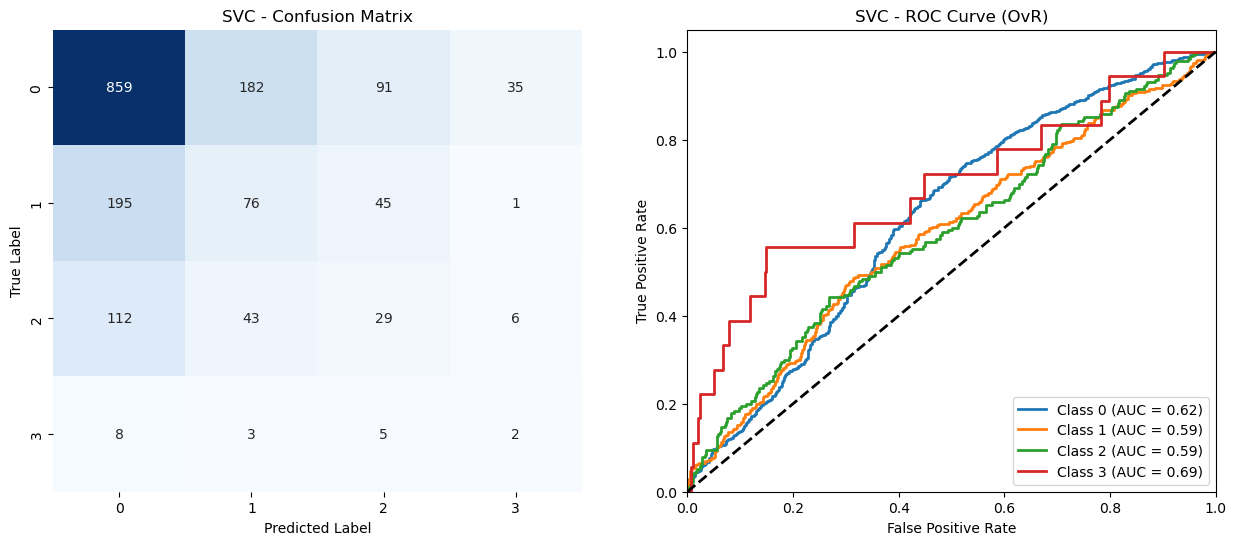

In [3]:
def load(stem):
    """Load one model's best params from optuna trials/<stem>_clf_trials.csv."""
    return load_tuned_params(
        os.path.join(PATHS["results_dir"], f"{stem}_clf_trials.csv"))


# Display name -> (estimator class, trials-CSV stem).
model_specs = {
    "LightGBM": (lgb.LGBMClassifier, "lgbm"),
    "XGBoost": (xgb.XGBClassifier, "xgb"),
    "CatBoost": (cb.CatBoostClassifier, "cb"),
    "RandomForest": (RandomForestClassifier, "rf"),
    "RidgeClassifier": (RidgeClassifier, "ridge"),
    "LogisticRegression": (LogisticRegression, "lr"),
    "SVC": (SVC, "svc"),
}

fitted_models = {}
for name, (model_class, stem) in model_specs.items():
    params, pca_n = load(stem)
    model = build_model(model_class, params, pca_n, EVAL_FIXED_PARAMS_CLF[name])

    if name == "XGBoost":
        sample_weight = class_weight.compute_sample_weight("balanced",
                                                           y_train_clf)
        model.fit(X_train_scaled, y_train_clf, model__sample_weight=sample_weight)
    else:
        model.fit(X_train_scaled, y_train_clf)

    if name == "RidgeClassifier":
        # Numerically stable row-wise softmax over the decision scores.
        scores = model.decision_function(X_test_scaled)
        exponentiated = np.exp(scores - np.max(scores, axis=1, keepdims=True))
        probabilities = exponentiated / exponentiated.sum(axis=1, keepdims=True)
    else:
        probabilities = model.predict_proba(X_test_scaled)

    evaluate_classifier(name, model, X_test_scaled, y_test_clf, probabilities,
                        y_test_binary=y_test_binary)
    fitted_models[name] = model

## 3. The PyTorch MLP

Built separately because its tuned parameters need unpacking (`n_layers` plus
one width per layer become a single `hidden_layers` list) and because it needs
no sample weights — `TorchClassifier` computes balanced class weights itself
and folds them into its loss function.


Evaluation for TorchClassifier
              precision    recall  f1-score   support

           0       0.80      0.61      0.69      1167
           1       0.27      0.27      0.27       317
           2       0.22      0.46      0.29       190
           3       0.02      0.11      0.04        18

    accuracy                           0.52      1692
   macro avg       0.33      0.36      0.32      1692
weighted avg       0.63      0.52      0.56      1692

Macro AUC: 0.6772


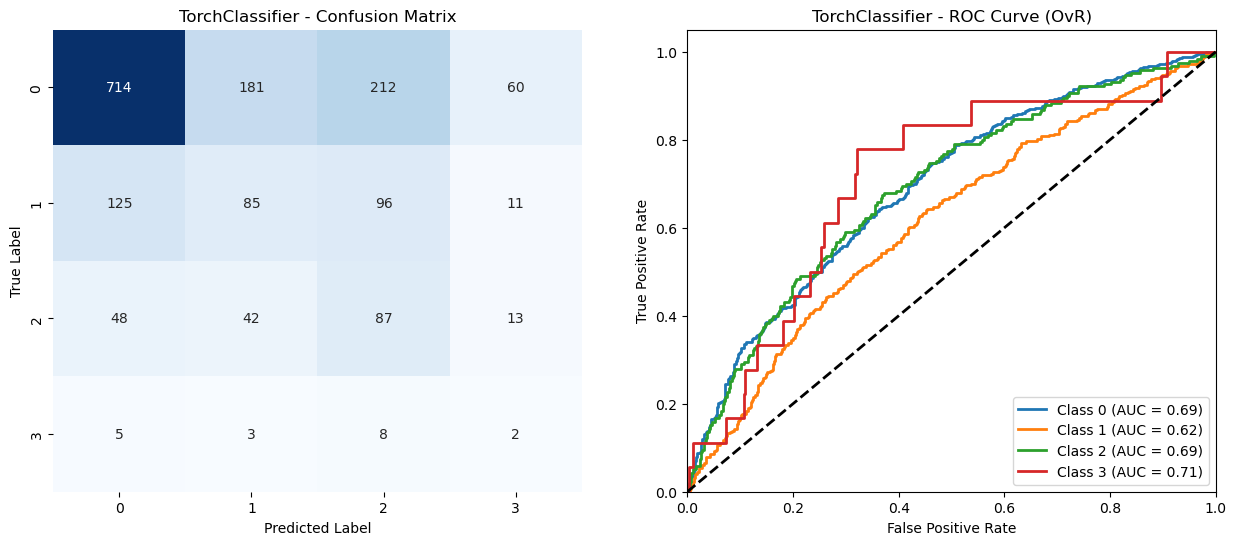

In [4]:
mlp_params, mlp_pca_n = load("nn")
m_nn = build_model(TorchClassifier, mlp_params, mlp_pca_n,
                   EVAL_FIXED_PARAMS_CLF["MLP"])
m_nn.fit(X_train_scaled, y_train_clf)

evaluate_classifier("TorchClassifier", m_nn, X_test_scaled, y_test_clf,
                    m_nn.predict_proba(X_test_scaled),
                    y_test_binary=y_test_binary)

## 4. Explaining the MLP

A neural network offers no feature importances of its own, which is exactly why
it is the interesting model to explain. Four complementary methods:

- **SHAP** — attributes each prediction to its features using Shapley values.
  Model-agnostic, and slow: it re-runs the pipeline hundreds of times per
  explanation.
- **LIME** — fits a small linear model in the neighbourhood of one instance.
- **TREPAN** — trains one global decision tree to imitate the network, judged
  on how often it *agrees with the network* rather than on accuracy.
- **LORE** — fits a local tree and reads off both the firing rule and a
  counter-factual: what would have to change for a different prediction.

All four run on the pre-PCA feature space, so their findings are stated in
terms of real, named features.

*Caveat carried over from the report:* the MLP is not the best classifier
(XGBoost is). Explaining a sub-optimal model risks attributing importance to
features the best model weighs differently — read these as illustrative of the
general importance landscape.

In [5]:
from src.explainability import (lime_explain, lore_explain, shap_explain,
                                trepan_explain)

feature_names = X_train_scaled.columns.tolist()
instance_idx = [0, 5, 10, 15]  # four test rows spanning several predicted classes

100%|██████████| 50/50 [00:00<00:00, 76.34it/s]



[SHAP] Global feature importance — class sii=0


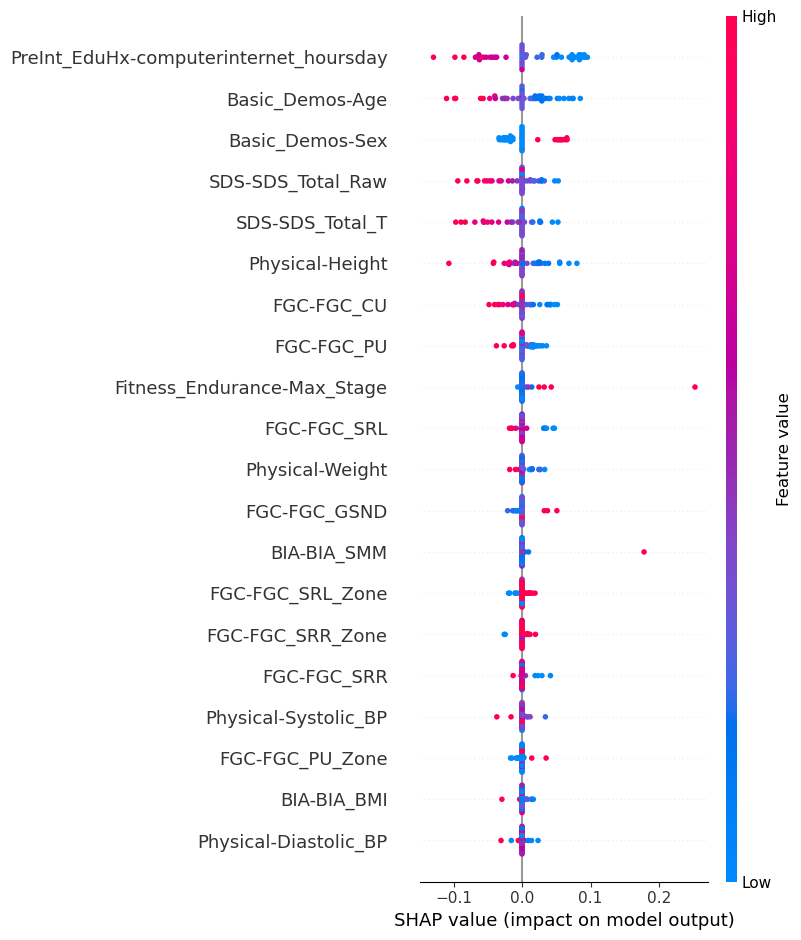


[SHAP] Mean |SHAP| across all classes


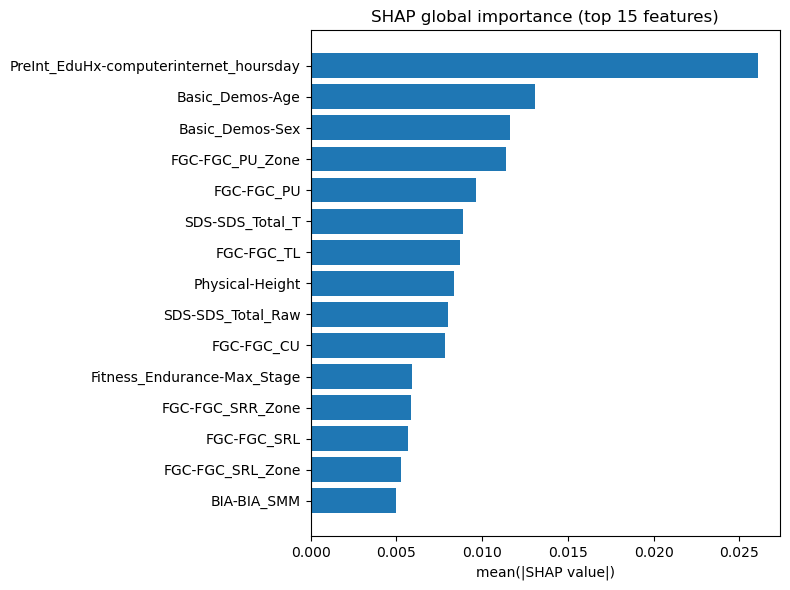

100%|██████████| 1/1 [00:00<00:00, 67.78it/s]


[SHAP] test idx=0, predicted sii=3 (Severe)


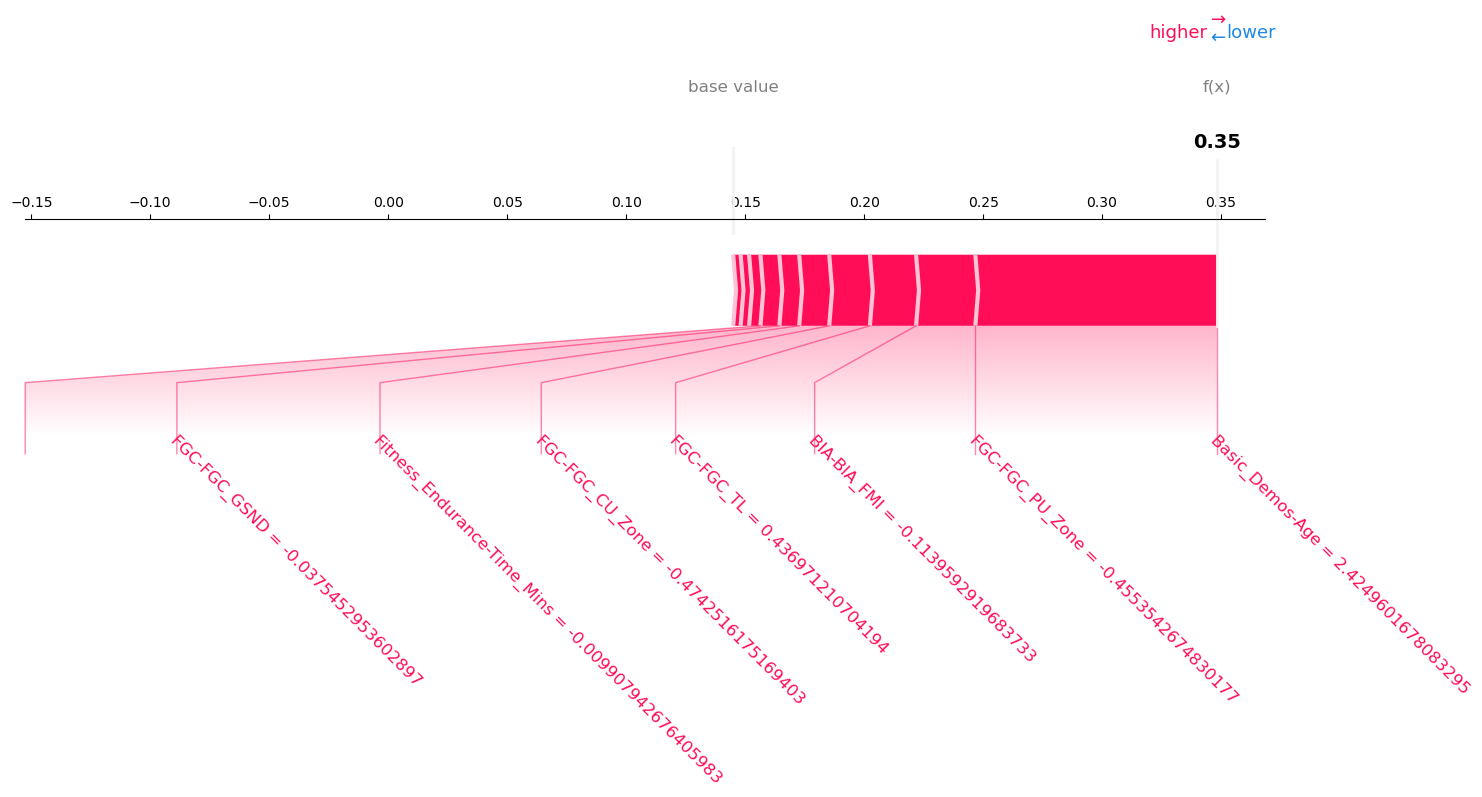

100%|██████████| 1/1 [00:00<00:00, 64.86it/s]



[SHAP] test idx=5, predicted sii=0 (None)


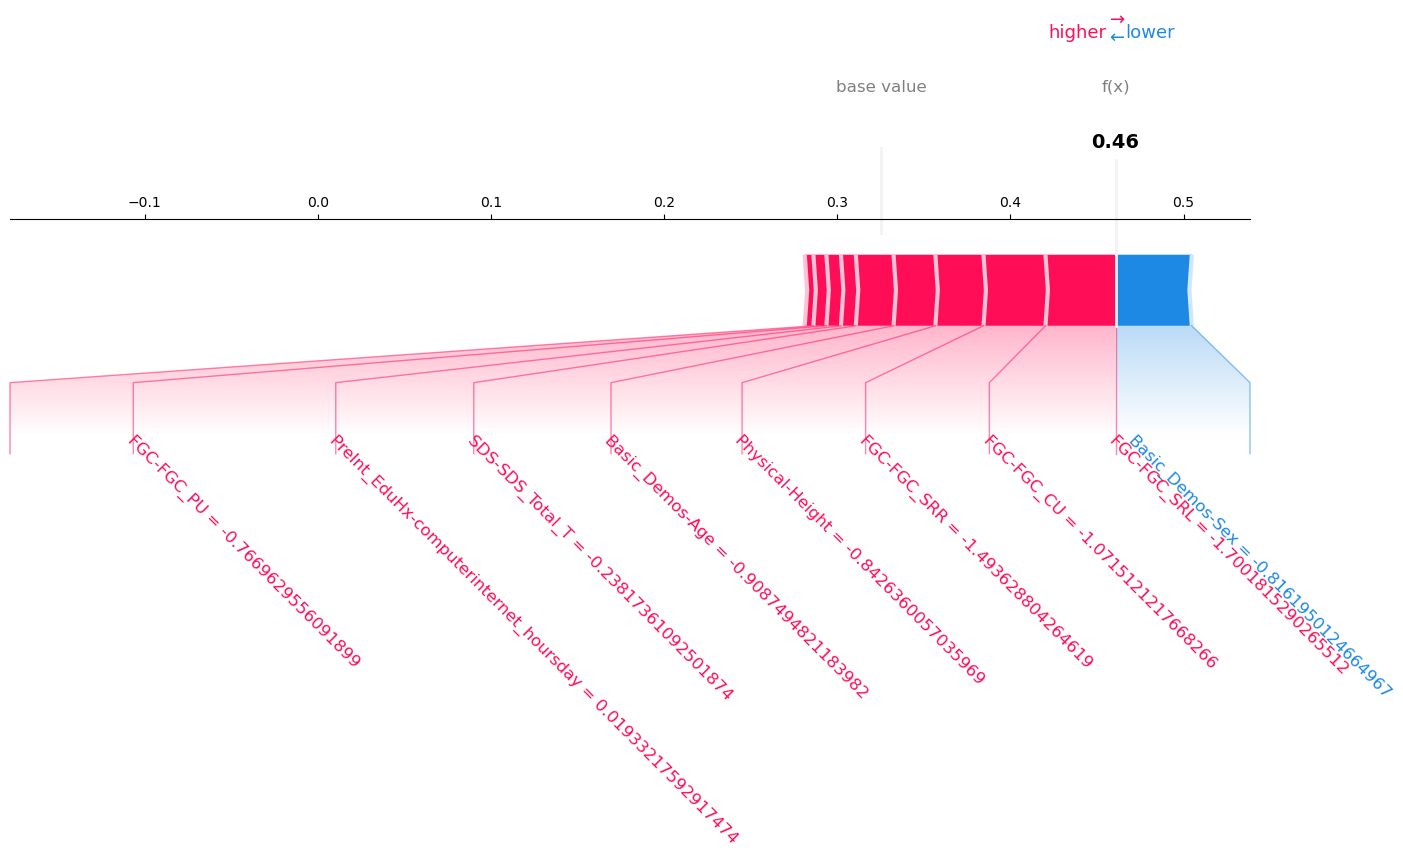

100%|██████████| 1/1 [00:00<00:00, 63.97it/s]



[SHAP] test idx=10, predicted sii=1 (Mild)


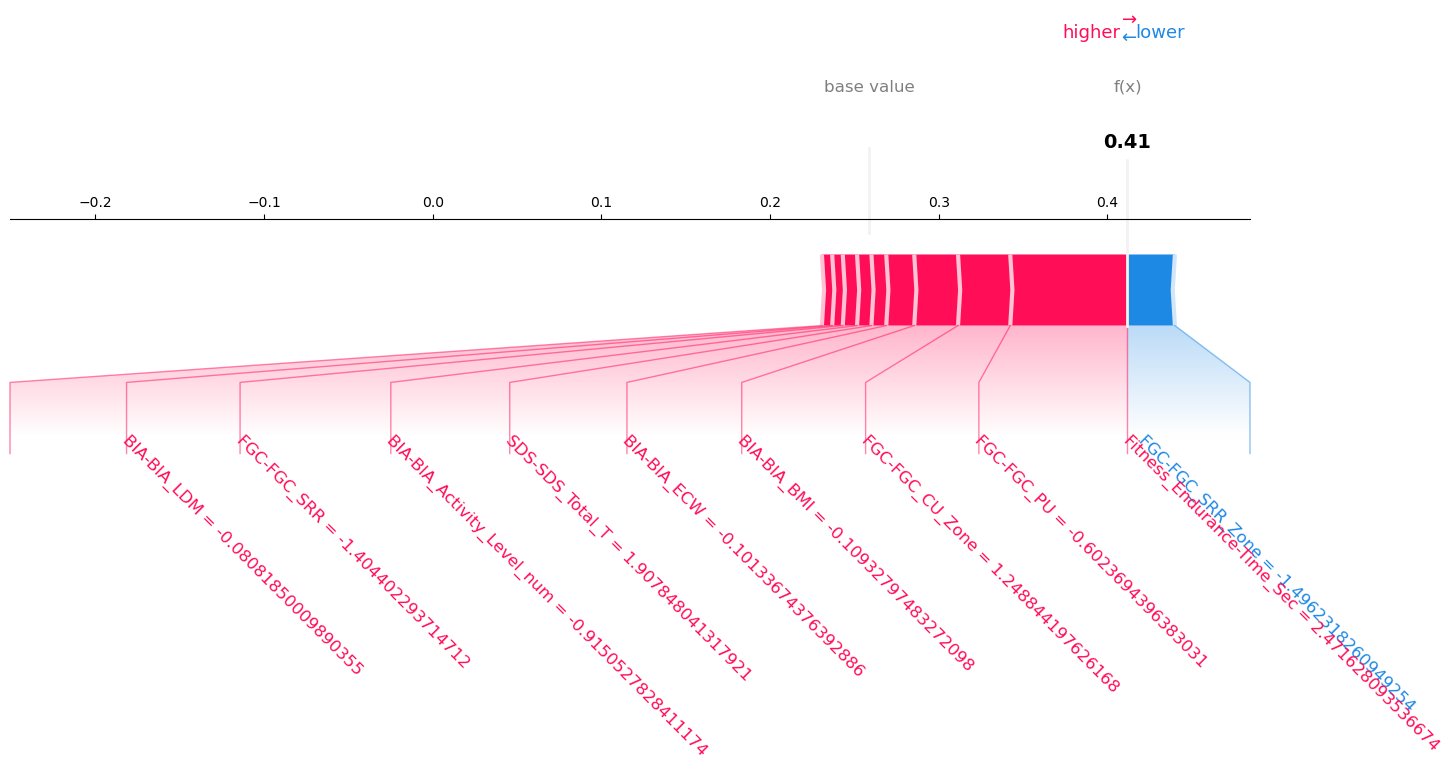

100%|██████████| 1/1 [00:00<00:00, 68.54it/s]



[SHAP] test idx=15, predicted sii=3 (Severe)


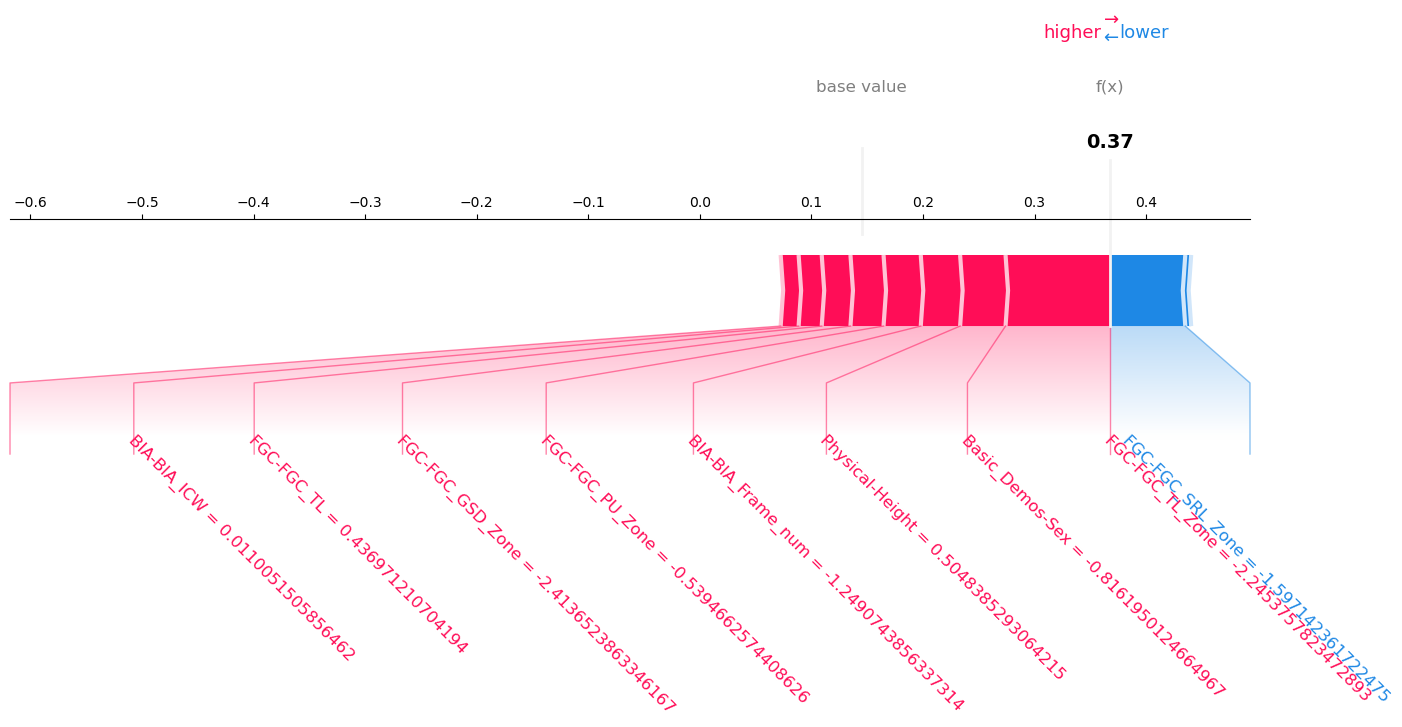

In [6]:
shap_explain(m_nn, X_train_scaled, X_test_scaled, feature_names,
             SII_CLASS_NAMES, instance_idx=instance_idx)


[LIME] test idx=0 — predicted sii=3 (Severe)
  - is_outlier <= -0.01: -0.1020
  + Basic_Demos-Age > 0.76: +0.0293
  + -0.54 < FGC-FGC_PU_Zone <= -0.38: +0.0250
  - 0.31 < FGC-FGC_TL_Zone <= 0.45: -0.0179
  + Basic_Demos-Sex <= -0.82: +0.0135
  - SDS-SDS_Total_Raw <= -0.25: -0.0133
  - -0.60 < FGC-FGC_PU <= -0.27: -0.0104
  + FGC-FGC_GSD_Zone > 0.12: +0.0098
  + -0.10 < BIA-BIA_ECW <= -0.07: +0.0093
  + 0.26 < FGC-FGC_TL <= 0.44: +0.0084


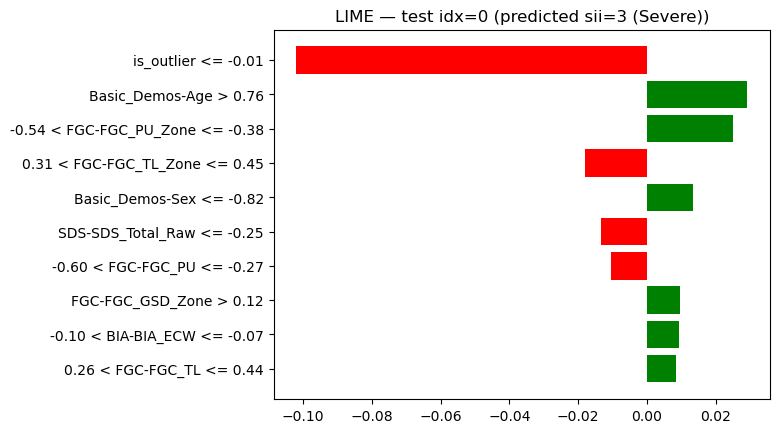


[LIME] test idx=5 — predicted sii=0 (None)
  + is_outlier <= -0.01: +0.1793
  + Basic_Demos-Age <= -0.63: +0.0742
  + Physical-Height <= -0.71: +0.0599
  + SDS-SDS_Total_Raw <= -0.25: +0.0573
  + FGC-FGC_CU <= -0.64: +0.0523
  + FGC-FGC_SRL <= -0.57: +0.0476
  - Basic_Demos-Sex <= -0.82: -0.0476
  + -0.94 < PreInt_EduHx-computerinternet_hoursday <= 0.02: +0.0382
  + FGC-FGC_PU <= -0.60: +0.0357
  - Physical-Diastolic_BP > 0.27: -0.0239


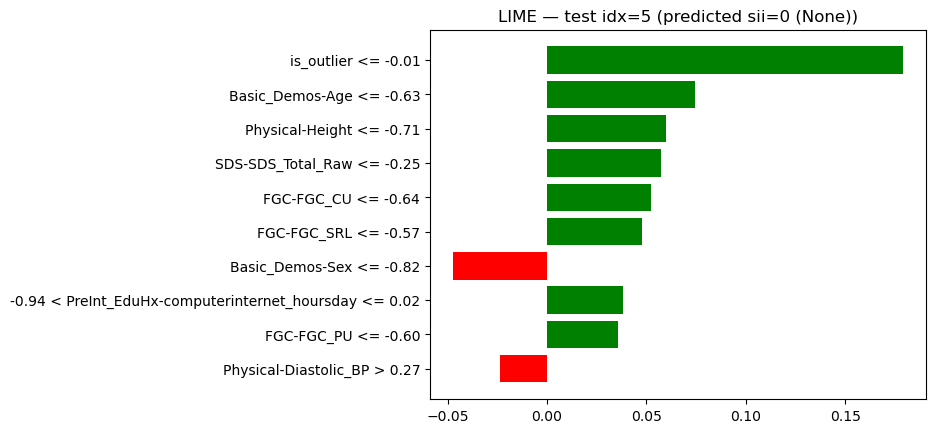


[LIME] test idx=10 — predicted sii=1 (Mild)
  - FGC-FGC_TL <= -0.35: -0.0460
  + FGC-FGC_PU <= -0.60: +0.0289
  + Fitness_Endurance-Time_Sec > 0.05: +0.0243
  + BIA-BIA_Activity_Level_num <= -0.92: +0.0215
  - FGC-FGC_PU_Zone <= -0.54: -0.0194
  + FGC-FGC_SRR <= -0.42: +0.0164
  - Basic_Demos-Age <= -0.63: -0.0137
  + BIA-BIA_SMM <= -0.12: +0.0129
  - PAQ_C-PAQ_C_Total <= -0.17: -0.0119
  - Physical-Diastolic_BP <= -0.46: -0.0106


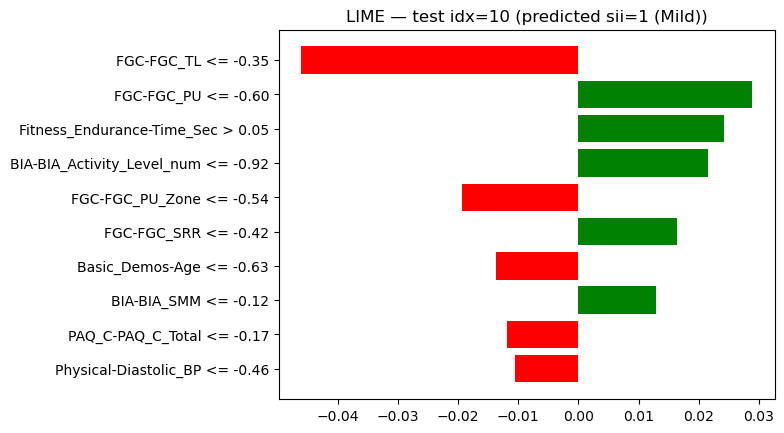


[LIME] test idx=15 — predicted sii=3 (Severe)
  + FGC-FGC_TL_Zone <= 0.31: +0.0238
  - FGC-FGC_PU <= -0.60: -0.0234
  - BIA-BIA_SMM > 0.02: -0.0222
  - BIA-BIA_ECW > 0.01: -0.0193
  - BIA-BIA_DEE > 0.01: -0.0171
  - BIA-BIA_BMC > -0.01: -0.0171
  + FGC-FGC_SRR > 0.29: +0.0168
  - FGC-FGC_SRL <= -0.57: -0.0167
  + Basic_Demos-Sex <= -0.82: +0.0156
  + 0.26 < FGC-FGC_TL <= 0.44: +0.0145


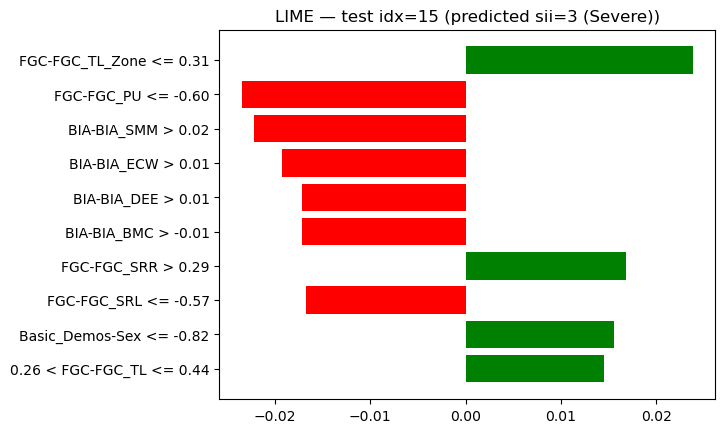

In [7]:
lime_explain(m_nn, X_train_scaled, X_test_scaled, feature_names,
             SII_CLASS_NAMES, instance_idx=instance_idx)


[TREPAN] Surrogate fidelity to MLP on test set: 0.6359
[TREPAN] Surrogate accuracy on true y_test:   0.4226

[TREPAN] Top-level rules:
|--- Basic_Demos-Age <= 0.06
|   |--- PreInt_EduHx-computerinternet_hoursday <= -0.04
|   |   |--- SDS-SDS_Total_T <= 0.48
|   |   |   |--- FGC-FGC_CU <= 0.29
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- FGC-FGC_CU >  0.29
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- SDS-SDS_Total_T >  0.48
|   |   |   |--- FGC-FGC_PU <= 2.44
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- FGC-FGC_PU >  2.44
|   |   |   |   |--- truncated branch of depth 2
|   |--- PreInt_EduHx-computerinternet_hoursday >  -0.04
|   |   |--- FGC-FGC_CU_Zone <= 0.06
|   |   |   |--- PreInt_EduHx-computerinternet_hoursday <= 0.24
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- PreInt_EduHx-computerinternet_hoursday >  0.24
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- FGC-FGC_CU_Zone >  0.06
|   |  

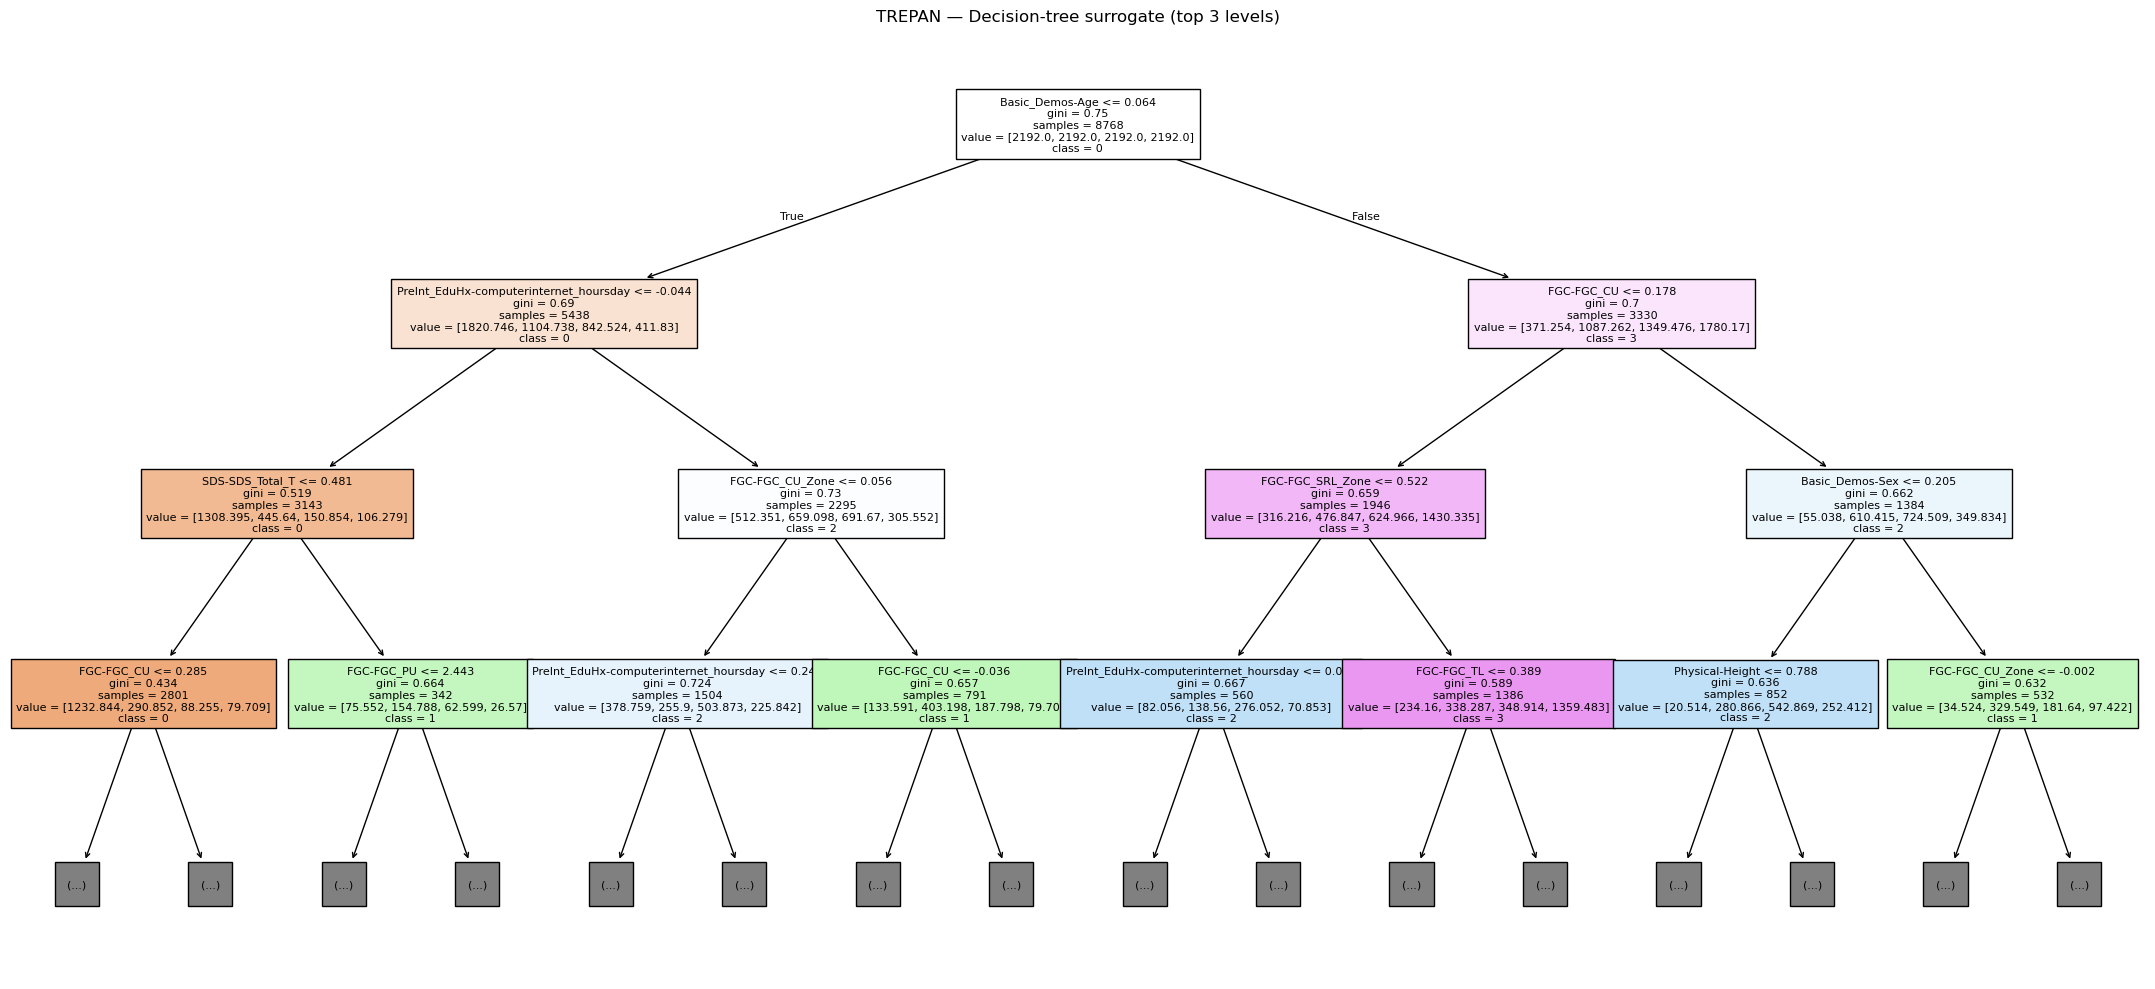

In [8]:
trepan_explain(m_nn, X_train_scaled, X_test_scaled, y_test_clf,
               feature_names)

In [9]:
lore_explain(m_nn, X_train_scaled, X_test_scaled, feature_names,
             SII_CLASS_NAMES, instance_idx=instance_idx)


[LORE] Local rule-based explanations

  test idx=0 | MLP → sii=3 (Severe) | local fidelity=0.495
  Rule (→ class 3): IF FGC-FGC_TL > -0.04 AND Basic_Demos-Sex <= -0.66 AND is_outlier > -0.05 AND FGC-FGC_SRL_Zone > 0.37
  Counter-factual (→ class 0): IF FGC-FGC_TL <= -0.04 AND BIA-BIA_ECW <= 0.06 AND FGC-FGC_CU <= -0.39 AND FGC-FGC_PU_Zone <= 0.24

  test idx=5 | MLP → sii=0 (None) | local fidelity=0.695
  Rule (→ class 0): IF FGC-FGC_CU <= -0.89 AND BIA-BIA_Fat > -0.01 AND PreInt_EduHx-computerinternet_hoursday <= 0.19 AND Fitness_Endurance-Time_Sec > -0.67
  Counter-factual (→ class 2): IF FGC-FGC_CU <= -0.89 AND BIA-BIA_Fat <= -0.01 AND BIA-BIA_ECW > 0.30 AND BIA-BIA_Frame_num > 0.62

  test idx=10 | MLP → sii=1 (Mild) | local fidelity=0.549
  Rule (→ class 1): IF FGC-FGC_CU > -1.06 AND SDS-SDS_Total_T > 1.85 AND PreInt_EduHx-computerinternet_hoursday > -1.53 AND FGC-FGC_TL > -1.14
  Counter-factual (→ class 2): IF FGC-FGC_CU <= -1.06 AND FGC-FGC_GSND <= -0.79 AND Physical-HeartRate

## 5. Stacking ensemble, tuned for Macro F1

Four deliberately different base learners — bagged trees, boosted trees, a
kernel method and the network — feed their class probabilities to a logistic
meta-learner.

Then one extra step that matters a lot here: taking the argmax of the stacked
probabilities optimises *accuracy*, which on this dataset mostly means
predicting class 0. So we search for one multiplier per class (Nelder-Mead,
clipped to [0.1, 10]) that maximises Macro F1 on the **training** predictions,
and apply those same multipliers to the test probabilities. The search
reliably boosts the rare classes and shrinks class 0.

The MLP is rebuilt here with `epochs=50` rather than 100, because the stacker
fits it five times over during its internal cross-validation.


[Stacking Ensemble Evaluation - Threshold Optimized for Macro F1]
Fitting Stacking Ensemble (this may take a few minutes)...
Optimizing probability thresholds directly for Macro F1...
Optimal Class Multipliers: [0.49579844 1.07549808 1.26706195 1.05107891]

--- Stacking Ensemble Performance (Macro F1 Optimized) ---
                  precision    recall  f1-score   support

    sii=0 (None)       0.78      0.84      0.81      1167
    sii=1 (Mild)       0.32      0.26      0.28       317
sii=2 (Moderate)       0.33      0.29      0.31       190
  sii=3 (Severe)       0.00      0.00      0.00        18

        accuracy                           0.66      1692
       macro avg       0.36      0.35      0.35      1692
    weighted avg       0.63      0.66      0.64      1692

Log Loss: 0.7723
QWK: 0.3412


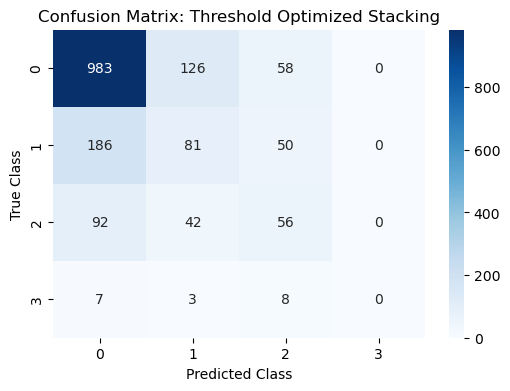

In [10]:
print("\n[Stacking Ensemble Evaluation - Threshold Optimized for Macro F1]")

stack_specs = {
    "rf": (RandomForestClassifier, "rf"),
    "xgb": (xgb.XGBClassifier, "xgb"),
    "svc": (SVC, "svc"),
    "nn": (TorchClassifier, "nn"),
}
stack_estimators = []
for key, (model_class, stem) in stack_specs.items():
    params, pca_n = load(stem)
    stack_estimators.append(
        (key, build_model(model_class, params, pca_n,
                          STACK_FIXED_PARAMS_CLF[key]))
    )

stacker, stack_predictions, multipliers, stack_probabilities = (
    build_classification_stack(X_train_scaled, y_train_clf, X_test_scaled,
                               y_test_clf, stack_estimators,
                               class_names=SII_CLASS_NAMES)
)